## Classification: "diamonds" dataset

1. Load Data
2. Visualize data (EDA)
3. Clean data: remove columns and/or rows
4. X/y Split
5. train_test_split. (if dataset is unbalanced, use stratify)
6. Fill/Encode/Scale Data: apply this only to the training set, then use those same parameters to transform the test set (binary encoding, one-hot encoding, cyclic encoding)
7. Check Correlation Matrix on the scaled/encoded training data
8. Pick Model & Check Training Curve: Use the default settings on your training data (via Cross-Validation) to check for overfitting
9. Grid Search: find best hyperparameters using the training set (use cross validation or validation set)
10. Train Final Model: Retrain the model on the entire training set using the best parameters found.
11. View Results: use the test set to generate your Confusion Matrix, precision/recall/F1-score
12. Find and plot most important features

In questo esempio, vogliamo stimare la variabile "cut" che è il livello di lucentezza di un diamante ("Fair", "Good", "Premium", etc.)

---

In [1]:
# 1. load data
import pandas as pd

df = pd.read_csv("regression_diamonds.csv")

In [2]:
#2. visualize data (EDA)
df

,id,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
# Controlliamo i tipi delle colonne e se ci sono valori nulli
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       53940 non-null  int64  
 1   carat    53940 non-null  float64
 2   cut      53940 non-null  object 
 3   color    53940 non-null  object 
 4   clarity  53940 non-null  object 
 5   depth    53902 non-null  float64
 6   table    53940 non-null  float64
 7   price    53940 non-null  int64  
 8   x        53940 non-null  float64
 9   y        53940 non-null  float64
 10  z        53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [4]:
# Per le colonne categoriche (tipo "object"),
# può essere utile fare un conteggio di ciascuna categoria:

cat_columns = ["cut", "color", "clarity"]
for col in cat_columns:
    print(df[col].value_counts())
    print()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64



In [28]:
# Controlliamo meglio se ci sono valori nulli
df.isna().sum()

id          0
carat       0
cut         0
color       0
clarity     0
depth      38
table       0
price       0
x           0
y           0
z           0
dtype: int64

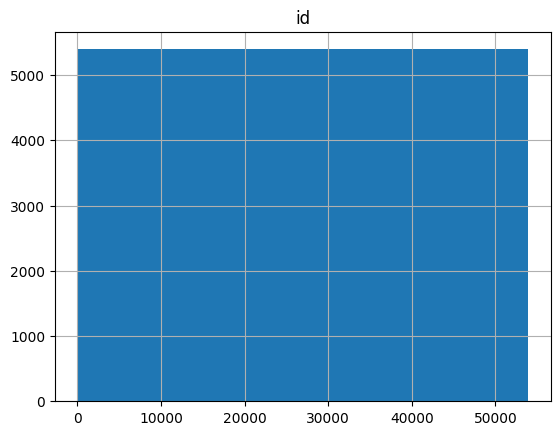

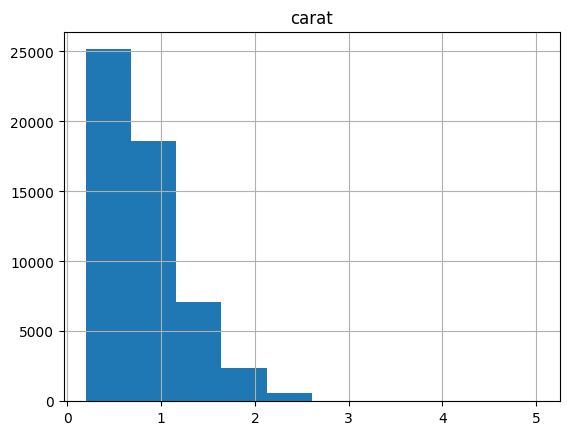

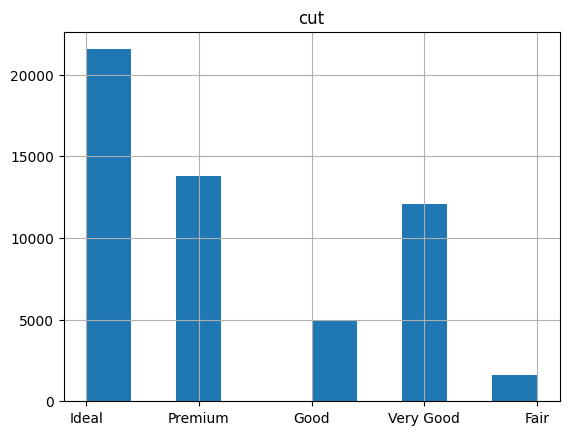

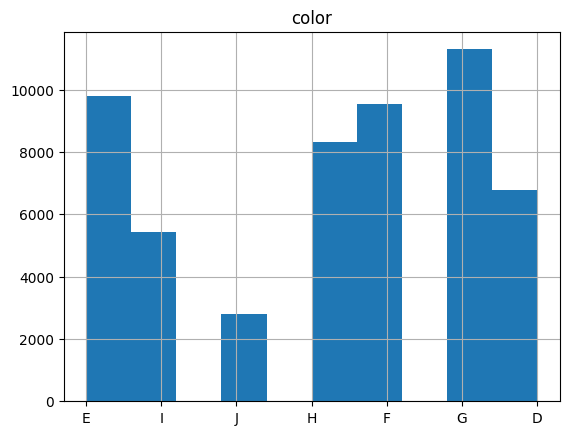

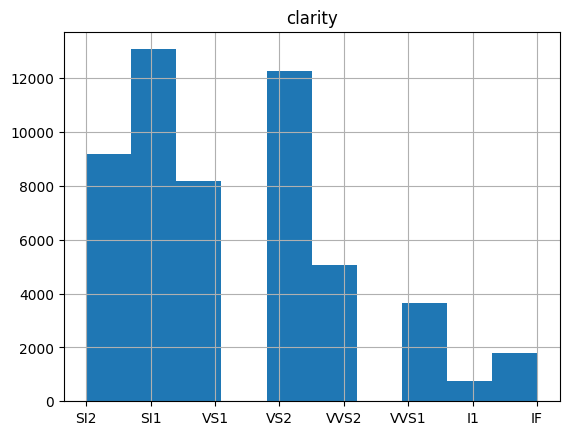

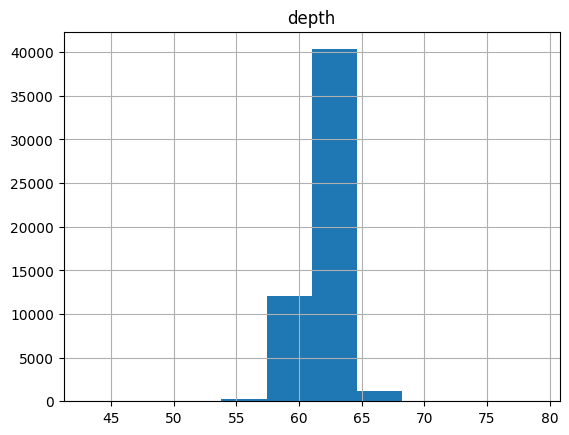

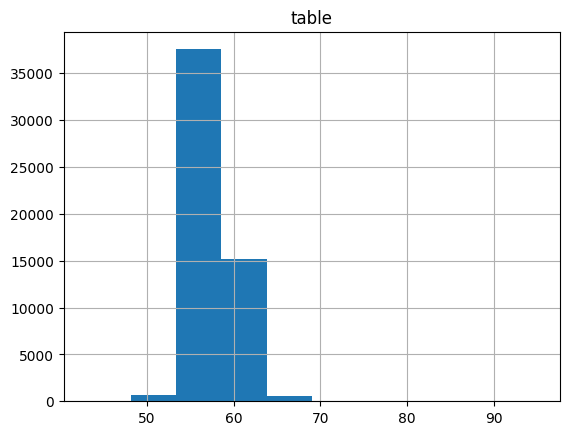

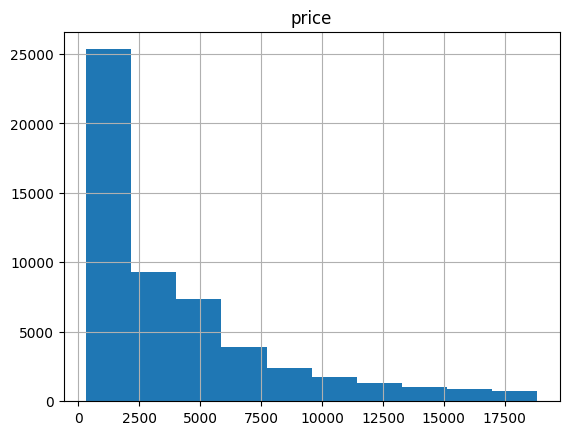

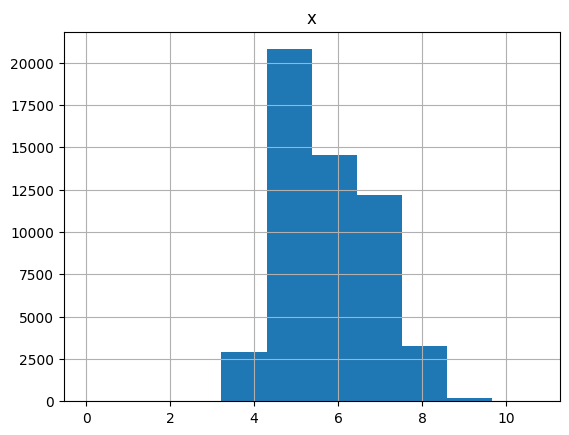

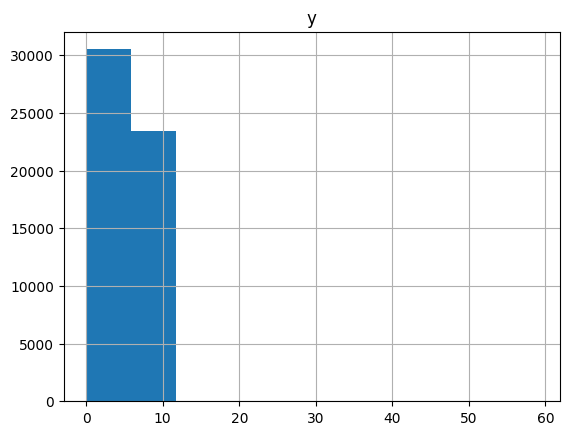

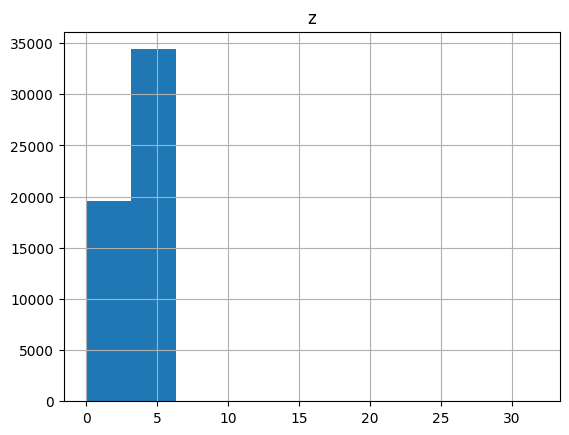

In [29]:
def plot_histograms(df):
    '''Print histogram for all columns'''
    import matplotlib.pyplot as plt
    for col in df.columns:
        plt.figure()
        df[col].hist()
        plt.title(col)
        plt.show()

plot_histograms(df)

In [5]:
# 3. Clean data: remove columns and/or rows

df_clean = df.copy()

# Remove entire 'id' column because it's irrelevant for predictions:
df_clean = df_clean.drop(columns=["id"])

# Remove rows with null values in a certain column:
# (skip this for now because we will be filling them with the column average)
# df_clean = df_clean.dropna(subset=["depth"])

df_clean

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [7]:
# 4. X/y Split

# 'cut' è la variabile che dobbiamo stimare con il modello di classificazione
y = df_clean["cut"]
X = df_clean.drop(columns=["cut"])

In [8]:
# 5. train_test_split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Dati di train:", len(X_train))
print("Dati di test:", len(X_test))

Dati di train: 43152
Dati di test: 10788


In [9]:
# 6. Fill/Scale/Encode Data: apply this only to the training set, then use those same parameters to transform the test set

In [ ]:
# In this dataset, the column 'depth' has some missing values:

# 30 missing values in the training set:
X_train.isna().sum()

carat       0
color       0
clarity     0
depth      30
table       0
price       0
x           0
y           0
z           0
dtype: int64

In [ ]:
# 8 missing values in the test set:
X_test.isna().sum()

carat      0
color      0
clarity    0
depth      8
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [12]:
# 6.1 Fill missing values using the mean/median/mode (must be calculated from the training set only)

X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

average_depth = X_train_filled["depth"].mean()

X_train_filled["depth"] = X_train_filled["depth"].fillna(average_depth) # Fill the column on the TRAIN set
X_test_filled["depth"] = X_test_filled["depth"].fillna(average_depth)   # Fill the column on the TEST set

# Check that there are no more missing values
X_train_filled.isna().sum()

carat      0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [14]:
# 6.2 Encode a column manually

X_train_encoded = X_train_filled.copy()
X_test_encoded = X_test_filled.copy()

# Encode "clarity column"

clarity_encoding = {
  'IF': 8,
  'VVS1': 7,
  'VVS2': 6,
  'VS1': 5,
  'VS2': 4,
  'SI1': 3,
  'SI2': 2,
  'I1': 1,
}

X_train_encoded['clarity'] = X_train_encoded['clarity'].map(clarity_encoding)
X_test_encoded['clarity'] = X_test_encoded['clarity'].map(clarity_encoding)

X_train_encoded

,carat,color,clarity,depth,table,price,x,y,z
24860,1.51,G,6,63.8,59.0,13275,7.28,7.24,4.63
45675,0.52,E,4,62.5,60.0,1694,5.14,5.10,3.20
22229,1.59,H,3,61.4,55.0,10284,7.56,7.51,4.63
24437,2.12,H,2,62.3,58.0,12693,8.25,8.16,5.12
9766,1.02,F,2,62.4,55.0,4662,6.46,6.43,4.02
...,...,...,...,...,...,...,...,...,...
39320,0.37,D,6,61.0,60.0,1071,4.61,4.64,2.82
2097,0.77,G,4,62.1,56.0,3114,5.85,5.88,3.64
46438,0.58,F,5,61.9,54.0,1772,5.33,5.37,3.31
11772,1.21,H,2,58.2,59.0,5082,7.05,7.03,4.10


In [ ]:
# Encode 'y' target variable ("cut")

cut_encoding = {
  'Ideal': 5,
  'Premium': 4,
  'Very Good': 3,
  'Good': 2,
  'Fair': 1,
}

y_train_encoded = y_train.copy().map(cut_encoding)
y_test_encoded = y_test.copy().map(cut_encoding)

# Print the column, notice that the type has been converted from 'object' to 'int64'
y_train_encoded

24860    2
45675    4
22229    5
24437    4
9766     5
        ..
39320    4
2097     5
46438    5
11772    4
28702    3
Name: cut, Length: 43152, dtype: int64

In [20]:
# Use one-hot encoding to encode a categorical column
# This is an alternative to ordinal encoding for non-ordered categories
from sklearn.preprocessing import OneHotEncoder

def one_hot_encode(X_train: pd.DataFrame, X_test: pd.DataFrame, columns_to_encode: list[str]) -> tuple[pd.DataFrame]:
    """Applies one-hot encoding to the specified columns"""

    X_train_encoded = X_train.copy()
    X_test_encoded = X_test.copy()

    one_hot_encoder = OneHotEncoder(
        sparse_output=False,  # Output a full matrix of 0 and 1 instead of a lightweight "sparse" matrix of just ones
        handle_unknown="ignore",
    ).set_output(transform="pandas") # Otherwise the encoder outputs a numpy array instead of a pandas dataframe

    new_encoded_columns = one_hot_encoder.fit_transform(X_train_encoded[columns_to_encode])

    # Add the new columns to the original TRAIN dataframe
    X_train_encoded = pd.concat(
        [
            X_train_encoded.reset_index(drop=True),
            new_encoded_columns.reset_index(drop=True),
        ],
        axis=1,
    )

    # Add the new columns to the original dataframe
    new_encoded_columns = one_hot_encoder.transform(X_test_encoded[columns_to_encode])
    X_test_encoded = pd.concat(
        [
            X_test_encoded.reset_index(drop=True),
            new_encoded_columns.reset_index(drop=True),
        ],
        axis=1,
    )  # Add the new columns to the original TEST dataframe

    # Remove original unencoded columns
    X_train_encoded = X_train_encoded.drop(columns=columns_to_encode)
    X_test_encoded = X_test_encoded.drop(columns=columns_to_encode)

    return X_train_encoded, X_test_encoded


X_train_1h_encoded, X_test_1h_encoded = one_hot_encode(X_train_encoded, X_test_encoded, columns_to_encode=["color"])

# Print result
X_train_1h_encoded

,carat,clarity,depth,table,price,x,y,z,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,1.51,6,63.8,59.0,13275,7.28,7.24,4.63,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.52,4,62.5,60.0,1694,5.14,5.10,3.20,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.59,3,61.4,55.0,10284,7.56,7.51,4.63,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2.12,2,62.3,58.0,12693,8.25,8.16,5.12,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.02,2,62.4,55.0,4662,6.46,6.43,4.02,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43147,0.37,6,61.0,60.0,1071,4.61,4.64,2.82,1.0,0.0,0.0,0.0,0.0,0.0,0.0
43148,0.77,4,62.1,56.0,3114,5.85,5.88,3.64,0.0,0.0,0.0,1.0,0.0,0.0,0.0
43149,0.58,5,61.9,54.0,1772,5.33,5.37,3.31,0.0,0.0,1.0,0.0,0.0,0.0,0.0
43150,1.21,2,58.2,59.0,5082,7.05,7.03,4.10,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [21]:
# 6.3 Scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train_1h_encoded)
X_test_scaled = scaler.transform(X_test_1h_encoded)

X_train_scaled

,carat,clarity,depth,table,price,x,y,z,color_D,color_E,color_F,color_G,color_H,color_I,color_J
0,1.499923,1.188499,1.425696,0.689559,2.339600,1.380655,1.309382,1.538984,-0.379684,-0.470162,-0.463388,1.942673,-0.427586,-0.332423,-0.235748
1,-0.587535,-0.028874,0.519751,1.136282,-0.561883,-0.529282,-0.554603,-0.480828,-0.379684,2.126925,-0.463388,-0.514755,-0.427586,-0.332423,-0.235748
2,1.668606,-0.637561,-0.246819,-1.097333,1.590240,1.630553,1.544557,1.538984,-0.379684,-0.470162,-0.463388,-0.514755,2.338710,-0.332423,-0.235748
3,2.786134,-1.246247,0.380374,0.242836,2.193787,2.246374,2.110721,2.231087,-0.379684,-0.470162,-0.463388,-0.514755,2.338710,-0.332423,-0.235748
4,0.466737,-1.246247,0.450062,-1.097333,0.181714,0.648810,0.603855,0.677385,-0.379684,-0.470162,2.158021,-0.514755,-0.427586,-0.332423,-0.235748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43147,-0.903817,1.188499,-0.525572,1.136282,-0.717968,-1.002303,-0.955272,-1.017562,2.633767,-0.470162,-0.463388,-0.514755,-0.427586,-0.332423,-0.235748
43148,-0.060399,-0.028874,0.240998,-0.650610,-0.206119,0.104389,0.124793,0.140652,-0.379684,-0.470162,-0.463388,1.942673,-0.427586,-0.332423,-0.235748
43149,-0.461023,0.579812,0.101622,-1.544056,-0.542341,-0.359708,-0.319427,-0.325458,-0.379684,-0.470162,2.158021,-0.514755,-0.427586,-0.332423,-0.235748
43150,0.867360,-1.246247,-2.476840,0.689559,0.286940,1.175381,1.126467,0.790382,-0.379684,-0.470162,-0.463388,-0.514755,2.338710,-0.332423,-0.235748


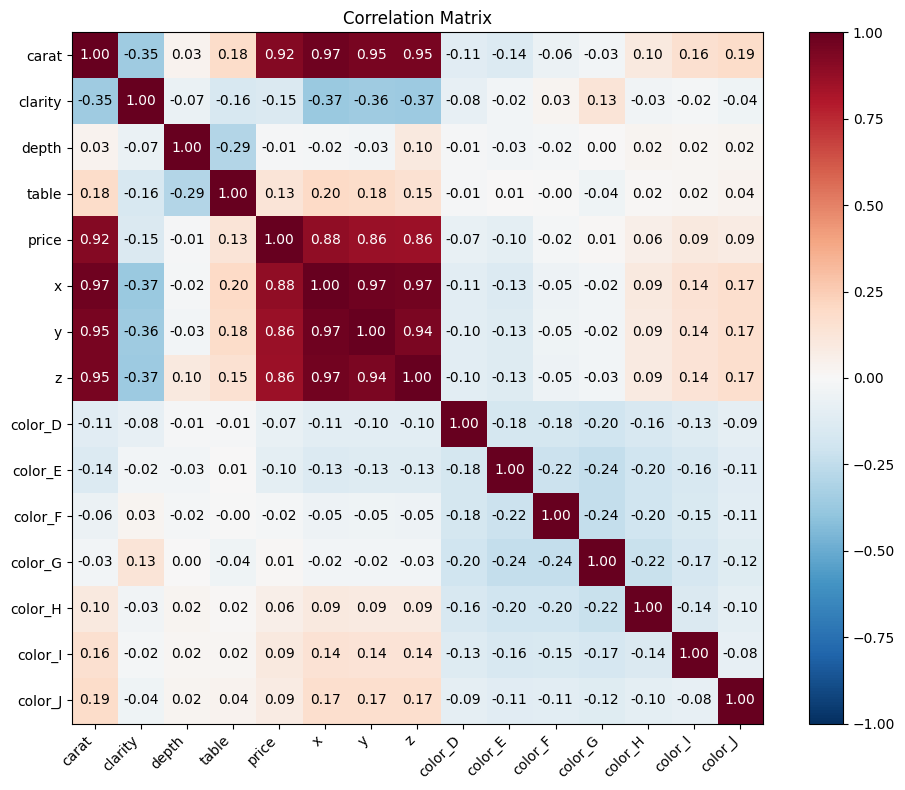

In [22]:
# 7. Check Correlation Matrix on the scaled/encoded training data


def show_correlation_matrix(df: pd.DataFrame):
    """
    Pure Matplotlib heatmap with automated text coloring for readability.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    corr = df.corr()
    fig, ax = plt.subplots(figsize=(10, 8))

    # Use 'RdBu_r' (reversed) so Red is positive, Blue is negative
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im)

    # Labels
    ticks = np.arange(len(corr.columns))
    ax.set_xticks(ticks)
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(ticks)
    ax.set_yticklabels(corr.columns)

    # Add text annotations with contrast logic
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            # Use white text for very dark colors (strong correlations)
            color = "white" if abs(val) > 0.7 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

    ax.set_title("Correlation Matrix")
    fig.tight_layout()
    plt.show()

show_correlation_matrix(X_train_scaled)

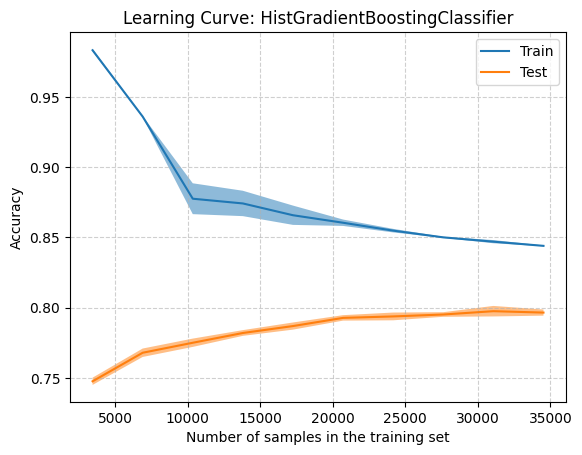

In [28]:
# 8. Pick Model & Check Training Curve: Use the default settings on your training data (via Cross-Validation) to check for overfitting

from sklearn.ensemble import HistGradientBoostingClassifier

import matplotlib.pyplot as plt
from sklearn.model_selection import LearningCurveDisplay
import numpy as np

def plot_learning_curve(model, X, y, classification: bool, cv=5):
    """
    Displays data size vs score. LearningCurveDisplay uses matplotlib under the hood.
    """

    display = LearningCurveDisplay.from_estimator(
        model,
        X,
        y,
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy" if classification else "r2",
    )
    display.ax_.set_title(f"Learning Curve: {model.__class__.__name__}")
    display.ax_.grid(True, linestyle="--", alpha=0.6)
    plt.show()


model = HistGradientBoostingClassifier()
plot_learning_curve(model, X_train_scaled, y_train_encoded, classification=True)

In [ ]:
# 9. Grid Search: find best hyperparameters using the training set (use cross validation or validation set)

from sklearn.model_selection import GridSearchCV

param_grid = {
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_iter': [100, 200, 400],
    'max_leaf_nodes': [15, 31, 63],
    'min_samples_leaf': [50, 100, 200],
    'l2_regularization': [0.0, 0.5, 1.0, 5.0],
    'early_stopping': [True],
}

grid_search = GridSearchCV(model, param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train_encoded)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'early_stopping': True, 'l2_regularization': 5.0, 'max_iter': 400, 'max_leaf_nodes': 15, 'min_samples_leaf': 50}
Best score: 0.8002872611633427


In [33]:
# 10. Train Final Model: Retrain the model on the entire training set using the best parameters found

best_params = {'early_stopping': True, 'l2_regularization': 5.0, 'max_iter': 400, 'max_leaf_nodes': 15, 'min_samples_leaf': 50}

best_model = HistGradientBoostingClassifier(**best_params) # Pass a dictionary as parameters
best_model.fit(X_train_scaled, y_train_encoded)
y_pred = best_model.predict(X_test_scaled)

In [ ]:
# 11. View Results: use the test set to generate your Confusion Matrix, precision/recall/F1-score

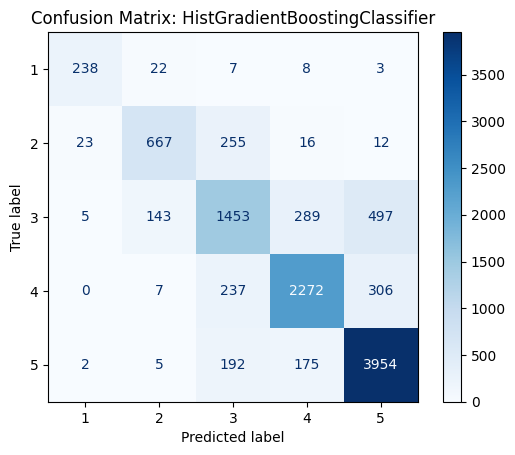

In [39]:
# Confusion matrix

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def show_confusion_matrix(model, y_test, y_pred):
    """Standard confusion matrix plot using Matplotlib backend."""
    if not hasattr(model, "classes_"):
        print("Model does not have classes_ attribute.")
        return

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(
        cmap="Blues", values_format=".4g"
    )  # values_format prevents scientific notation
    plt.title(f"Confusion Matrix: {model.__class__.__name__}")
    plt.show()

show_confusion_matrix(best_model, y_test_encoded, y_pred)

In [40]:
# Precision/recall/F1-score

from sklearn.metrics import classification_report

def get_classification_report(y_true, y_pred, target_names: list[str] | None = None) -> pd.DataFrame:
    """Converts sklearn report to a DataFrame."""
    report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    return pd.DataFrame(report_dict).transpose()

get_classification_report(y_test_encoded, y_pred)

,precision,recall,f1-score,support
1,0.888060,0.856115,0.871795,278.000000
2,0.790284,0.685509,0.734177,973.000000
3,0.677705,0.608714,0.641360,2387.000000
4,0.823188,0.805103,0.814045,2822.000000
5,0.828583,0.913586,0.869011,4328.000000
accuracy,0.795699,0.795699,0.795699,0.795699
macro avg,0.801564,0.773805,0.786078,10788.000000
weighted avg,0.791867,0.795699,0.792172,10788.000000


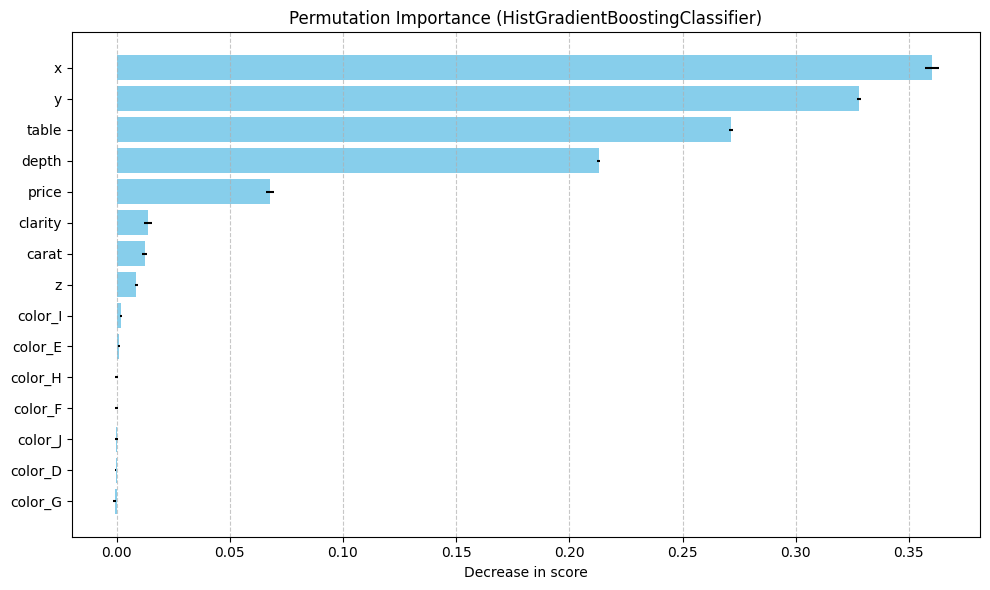

,Feature,Importance_Mean,Importance_Std
5,x,0.360234,0.002930
6,y,0.328050,0.000823
3,table,0.271468,0.001030
2,depth,0.212903,0.000846
4,price,0.067853,0.001675
1,clarity,0.014071,0.001730
0,carat,0.012366,0.001153
7,z,0.008639,0.000649
13,color_I,0.002002,0.000364
9,color_E,0.001168,0.000324


In [ ]:
# Find and plot most important features

import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

def check_permutation_importance(trained_model, X_test, y_test, n_repeats):
    """
    Calculates and plots permutation importance for a trained model
    """
    # Calculate importance
    result = permutation_importance(trained_model, X_test, y_test, n_repeats=n_repeats, n_jobs=-1)
    
    # Organize into a DataFrame
    importance_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance_Mean": result.importances_mean,
        "Importance_Std": result.importances_std
    }).sort_values(by="Importance_Mean", ascending=False)
    
    # Visualization
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance_Mean"], 
             xerr=importance_df["Importance_Std"], color='skyblue')
    plt.xlabel("Decrease in score")
    plt.title(f"Permutation Importance ({trained_model.__class__.__name__})")
    plt.gca().invert_yaxis()  # Put highest importance at the top
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return importance_df


check_permutation_importance(best_model, X_test_scaled, y_test_encoded, n_repeats=5)